# Lifestyle classification (westernized vs. non-westernized) from microbiome profiles

*Contents:*

1. Setup
2. Prepare data
3. Prediction functions
4. Fit the classifier (all SGBs)
5. Study-composition checks
6. Main result: leave-studies-out ROC
7. Example feature: *P. copri* abundance by lifestyle
8. Feature importance

## 1. Setup

In [1]:
import os
print("Working directory:", os.getcwd())
print("Conda environment:", os.environ.get('CONDA_DEFAULT_ENV'))

Working directory: /shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/wnw/notebooks
Conda environment: wnw


In [2]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json

from joblib import Parallel, delayed
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score, roc_curve, auc,
    ConfusionMatrixDisplay
)

from sklearn.metrics import roc_curve, auc
plt.rcParams['svg.fonttype'] = 'none'

## 2. Prepare data

### Metadata

In [3]:
basedir = '/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/'
metadata = pd.read_table(os.path.join(basedir,'nw_metadata.tsv'))
metadata.head(5)

,study_name,sample_id,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,...,non_westernized,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
0,NielsenHB_2014,O2_UC49_0,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,60584637.0,4.099972e+09,30.0,70.0,ERR210493;ERR210492;ERR209641;ERR209640,Paolo_Manghi,NaN
1,NielsenHB_2014,O2_UC49_2,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,56508214.0,3.775477e+09,30.0,70.0,ERR210495;ERR210494;ERR209643;ERR209642,Paolo_Manghi,NaN
2,NielsenHB_2014,O2_UC50_0,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,65105855.0,4.392995e+09,30.0,71.0,ERR210497;ERR210496;ERR209645;ERR209644,Paolo_Manghi,NaN
3,NielsenHB_2014,O2_UC50_2,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,53260679.0,3.596382e+09,30.0,70.0,ERR210500;ERR209648,Paolo_Manghi,NaN
4,NielsenHB_2014,O2_UC51_0,O2_UC51,stool,NaN,control,healthy,32.0,adult,female,...,no,IlluminaHiSeq,24997787.0,57486896.0,3.923766e+09,30.0,72.0,ERR210502;ERR210501;ERR209650;ERR209649,Paolo_Manghi,NaN


Filter metadata: only keep samples from adults. `ancient_adult_metadata` is built here but not used again — the classifier only ever runs on `adults_metadata`.

In [4]:
# Filter metadata
adults_metadata = metadata[metadata['age'] != pd.NA]
adults_metadata = adults_metadata[adults_metadata['age'] != np.nan]
adults_metadata = adults_metadata[adults_metadata['age'].notna()]
adults_metadata = adults_metadata[adults_metadata['age'] != '1.083.333.333']
adults_metadata['age'] = adults_metadata['age'].astype(float)
adults_metadata = adults_metadata[adults_metadata['age'] > 16]
adults_metadata = adults_metadata[adults_metadata['study_name'] != 'HanniganGD_2017']
adults_metadata.index = adults_metadata['sample_id']

# Isolate metadata from ancient samples
# and append metadata from adults
ancient_metadata = metadata[metadata['non_westernized'] == 'ancient']
ancient_metadata.index = ancient_metadata['sample_id']
ancient_adult_metadata = ancient_metadata.append(adults_metadata)

# SUMMARY
n_per_group = ancient_adult_metadata.non_westernized.value_counts()
print("Total samples after filtering:",ancient_adult_metadata.shape[0])
print(
    "\nn samples per category:\n",
    "* Westernized:", n_per_group['no'], "\n",
    "* Non-westernized:", n_per_group['yes'], "\n",
    "* Ancient:", n_per_group['ancient'], "\n"
    )
ancient_adult_metadata.head(3)

Total samples after filtering: 6892

n samples per category:
 * Westernized: 5661 
 * Non-westernized: 1202 
 * Ancient: 29 



/tmp/ipykernel_1258439/1910342159.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  ancient_adult_metadata = ancient_metadata.append(adults_metadata)


,study_name,sample_id,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,...,non_westernized,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
sample_id,,,,,,,,,,,,,,,,,,,,,
2611_merged,CM_Coprolites_Austria_2019,2611_merged,2611_merged,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2612_Plus,CM_Coprolites_Austria_2019,2612_Plus,2612_Plus,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2604_merged,CM_Coprolites_Austria_2019,2604_merged,2604_merged,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Relative abundances
`ancient_adult_abundances` is likewise unused below.

In [5]:
# Read file with SGB abundances
abundances = pd.read_table(os.path.join(basedir,'nw_profiles.tsv'), index_col=[0])

# Only keep SGBs with strain-level annotation
keep = list()
for x in abundances.index.tolist():
    keep.append('t__' in x)
sgb_abundances = abundances.loc[keep]

# Simplify annotation for SGBs
sgb_abundances.index = [x.split('|')[-2][3:].replace('_',' ') + ' (' + x.split('|')[-1][3:] +')' for x in sgb_abundances.index.tolist()]

# Subset abundance df with selected samples
adults_abundances = sgb_abundances[adults_metadata['sample_id']]
ancient_adult_abundances = sgb_abundances[ancient_adult_metadata['sample_id']]

# Remove SGBs that are totally absent in remaining samples
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())

# And similarly, remove samples that don't have any of the remaining SGBs in them
adults_abundances = adults_abundances.transpose()
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())

# Repeat for total dataset
ancient_adult_abundances = ancient_adult_abundances.drop(ancient_adult_abundances.loc[ancient_adult_abundances.sum(axis=1) == 0].index.tolist())
ancient_adult_abundances = ancient_adult_abundances.transpose()
ancient_adult_abundances = ancient_adult_abundances.drop(ancient_adult_abundances.loc[ancient_adult_abundances.sum(axis=1) == 0].index.tolist())

print('Number of SGBs after filtering:', ancient_adult_abundances.shape[1])

Number of SGBs after filtering: 4438


## 3. Prediction functions

In [6]:
def prepare_data_for_predictions(abundances, metadata):
 
    filtered = metadata.loc[abundances.index]

    sample_nw_bin = dict(filtered.non_westernized.map({'no':0,'yes':1}))

    nwest = filtered['non_westernized'].value_counts()['no']
    nnonwest = filtered['non_westernized'].value_counts()['yes']
    print('n West =',nwest)
    print('n Non-west =',nnonwest)

    # Validation
    studies = filtered['study_name'].unique()
    eligible_w = []
    eligible_nw = []
    for study in studies:
        selected_study = filtered[filtered['study_name'] == study]
        try:
            if selected_study.non_westernized.value_counts()['yes'] > 50:
                eligible_nw.append(study)
        except KeyError:
            pass
        try:
            if selected_study.non_westernized.value_counts()['no'] > 50:
                eligible_w.append(study)
        except KeyError:
            pass

    X = np.array(abundances.values)
    y = np.array(filtered.index.map(sample_nw_bin))

    X_pseudo = X + 1e-6
    gm = np.exp(np.log(X_pseudo).mean(axis=1, keepdims=True))  # shape (n_samples, 1)
    X_clr = np.log(X_pseudo / gm)  # broadcasting

    return X_clr, y, filtered, eligible_w, eligible_nw

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def eval_pair(X, y, study_w, study_nw, filtered_metadata):

    """
    Trains a RF classifier on all studies except the two specified (`study_w`, `study_nw`), 
    and evaluates on those two ('leave-one-study-pair-out cross-validation'). 
    
    Args:
        X (pd.DataFrame): Feature matrix with named columns.
        y (pd.Series or np.ndarray): Target labels corresponding to X.
        study_w (str): Name of the first held-out study.
        study_nw (str): Name of the second held-out study.
        filtered_metadata (pd.DataFrame): Metadata containing at least a 'study_name' column aligned with X/y.

    Returns:
        dict: Dictionary containing:
            - "study_w" (str): Name of the first held-out study.
            - "study_nw" (str): Name of the second held-out study.
            - "auc" (float): ROC AUC score on the held-out test set.
            - "y_true" (list): True labels for the test set.
            - "y_proba" (list): Predicted probabilities for the positive class.
            - "feature_importances" (dict): Feature importances mapped to feature names.
    """
    
    val_studies = [study_w, study_nw]
    val_idx = filtered_metadata['study_name'].isin(val_studies)
    train_idx = ~val_idx

    X_train = X[train_idx]
    y_train = y[train_idx]
    X_test = X[val_idx]
    y_test = y[val_idx]

    clf = RandomForestClassifier(
        n_estimators=50,  # faster
        class_weight='balanced',
        random_state=42,
        n_jobs=2
    )
    clf.fit(X_train, y_train)
    y_proba = clf.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)

    feature_importances = dict(zip(X.columns, clf.feature_importances_))

    return {
        "study_w": study_w,
        "study_nw": study_nw,
        "auc": auc,
        "y_true": y_test.tolist(),         
        "y_proba": y_proba.tolist(),
        "feature_importances": feature_importances
    }

In [7]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from itertools import combinations
import random

def prepare_data_for_predictions(abundances, metadata):
    filtered = metadata.loc[abundances.index]

    sample_nw_bin = dict(filtered.non_westernized.map({'no': 0, 'yes': 1}))

    nwest = filtered['non_westernized'].value_counts().get('no', 0)
    nnonwest = filtered['non_westernized'].value_counts().get('yes', 0)
    print('n West =', nwest)
    print('n Non-west =', nnonwest)

    # Identify eligible studies
    studies = filtered['study_name'].unique()
    eligible_w, eligible_nw = [], []

    for study in studies:
        study_data = filtered[filtered['study_name'] == study]
        counts = study_data.non_westernized.value_counts()
        if counts.get('yes', 0) > 50:
            eligible_nw.append(study)
        if counts.get('no', 0) > 50:
            eligible_w.append(study)

    X = abundances.values
    y = filtered.index.map(sample_nw_bin).to_numpy()

    # CLR transformation
    X_pseudo = X + 1e-6
    gm = np.exp(np.log(X_pseudo).mean(axis=1, keepdims=True))  # geometric mean
    X_clr = np.log(X_pseudo / gm)

    return X_clr, y, filtered, eligible_w, eligible_nw


def eval_leave_k_studies_out(X, y, filtered_metadata, eligible_w, eligible_nw, k=2, n_iters=30):
    """
    Implements leave-k-studies-out cross-validation.

    Args:
        X (np.ndarray): Feature matrix.
        y (np.ndarray): Labels.
        filtered_metadata (pd.DataFrame): Metadata indexed to X/y.
        eligible_w (list): List of eligible Western studies.
        eligible_nw (list): List of eligible Non-Western studies.
        k (int): Number of studies to leave out per group per iteration.
        n_iters (int): Number of iterations to run.

    Returns:
        list: Results per iteration (dicts with AUC, study names, predictions, importances).
    """

    results = []

    for iteration in range(n_iters):
        # Randomly select k studies from each group
        left_out_w = random.sample(eligible_w, min(k, len(eligible_w)))
        left_out_nw = random.sample(eligible_nw, min(k, len(eligible_nw)))
        val_studies = left_out_w + left_out_nw

        val_idx = filtered_metadata['study_name'].isin(val_studies)
        train_idx = ~val_idx

        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[val_idx], y[val_idx]

        clf = RandomForestClassifier(
            n_estimators=50,
            class_weight='balanced',
            random_state=iteration,
            n_jobs=2
        )
        clf.fit(X_train, y_train)
        y_proba = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)

        feature_importances = dict(zip(range(X.shape[1]), clf.feature_importances_))

        results.append({
            "iteration": iteration + 1,
            "left_out_w": left_out_w,
            "left_out_nw": left_out_nw,
            "auc": auc,
            "y_true": y_test.tolist(),
            "y_proba": y_proba.tolist(),
            "feature_importances": feature_importances
        })

    return results


## 4. Fit the classifier (all SGBs)

In [8]:
X_allsgb, y_allsgb, filtered_allsgb, eligible_w_allsgb, eligible_nw_allsgb = prepare_data_for_predictions(
    adults_abundances, 
    adults_metadata
)

n West = 5661
n Non-west = 1200


## 5. Study-composition checks
Two side questions the code answers before trusting the main model: whether two low-yield studies (`Obregon-TitoAJ_2015`, `RampelliS_2015`) should be excluded, and whether a classifier can pick out which *study* a sample came from (a proxy for batch effects) as easily as it picks out lifestyle.

In [9]:
adults_metadata.groupby("study_name").non_westernized.value_counts()

subset_meta = adults_metadata[~adults_metadata.study_name.isin(["Obregon-TitoAJ_2015", "RampelliS_2015"])]
study_to_nw = subset_meta[["study_name","non_westernized"]].reset_index(drop=True).drop_duplicates()
study_to_nw = dict(zip(study_to_nw.study_name, study_to_nw.non_westernized))

subset_meta[["study_name","non_westernized"]]

,study_name,non_westernized
sample_id,,
O2_UC49_0,NielsenHB_2014,no
O2_UC49_2,NielsenHB_2014,no
O2_UC50_0,NielsenHB_2014,no
O2_UC50_2,NielsenHB_2014,no
O2_UC51_0,NielsenHB_2014,no
...,...,...
C16-20627-TZ,CM_tanzania,yes
C16-20645-TZ,CM_tanzania,yes
C16-20646-TZ,CM_tanzania,yes


In [10]:
import pandas as pd
import numpy as np

# Example: load your dataframe
# df = pd.read_csv("your_data.tsv", sep="\t", index_col=0)

# 1. Get unique studies and their original label
study_labels = subset_meta.groupby("study_name")["non_westernized"].first()

# 2. Count how many 'yes' and 'no' studies there are
counts = study_labels.value_counts()

# 3. Permute: assign the same number of 'yes' and 'no' labels randomly to studies
shuffled_labels = np.repeat(counts.index.to_numpy(), counts.values)  # convert to ndarray
shuffled_labels = shuffled_labels.copy()  # ensure it's mutable
np.random.shuffle(shuffled_labels)  # shuffle in place

# 4. Map permuted labels back to studies
study_to_label = dict(zip(study_labels.index, shuffled_labels))

# 5. Apply permuted mapping to your original df
subset_meta["non_westernized_permuted"] = subset_meta["study_name"].map(study_to_label)

print((subset_meta["non_westernized"] == subset_meta["non_westernized_permuted"]).sum() / len(subset_meta))

# subset_meta["non_westernized"] = subset_meta["non_westernized_permuted"]

0.6082732224348594


/tmp/ipykernel_1258439/2989239871.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_meta["non_westernized_permuted"] = subset_meta["study_name"].map(study_to_label)


In [11]:
matching_samples = list(set(adults_abundances.index).intersection(set(list(subset_meta.index))))
abundances_subset = adults_abundances.loc[matching_samples]
meta_subset = subset_meta.loc[matching_samples]

Can a classifier tell studies apart from abundances alone? If it does about as well as chance, batch effects are less of a worry.

In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# Align metadata and abundances
meta = meta_subset.loc[abundances_subset.index]
X = abundances_subset.values
y = meta['study_name'].values

# Encode study_name into integer classes
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of studies: {len(le.classes_)}")

# Apply CLR transform (centered log-ratio)
X_pseudo = X + 1e-6
gm = np.exp(np.log(X_pseudo).mean(axis=1, keepdims=True))
X_clr = np.log(X_pseudo / gm)

clf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X_clr, y_encoded, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"Mean CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

Number of samples: 6791
Number of features: 4080
Number of studies: 56
Mean CV accuracy: 0.623 ± 0.002


In [13]:
meta.study_name.value_counts()[0] / meta.shape[0]

0.16713297010749523

t=369.56, p=3.217e-10


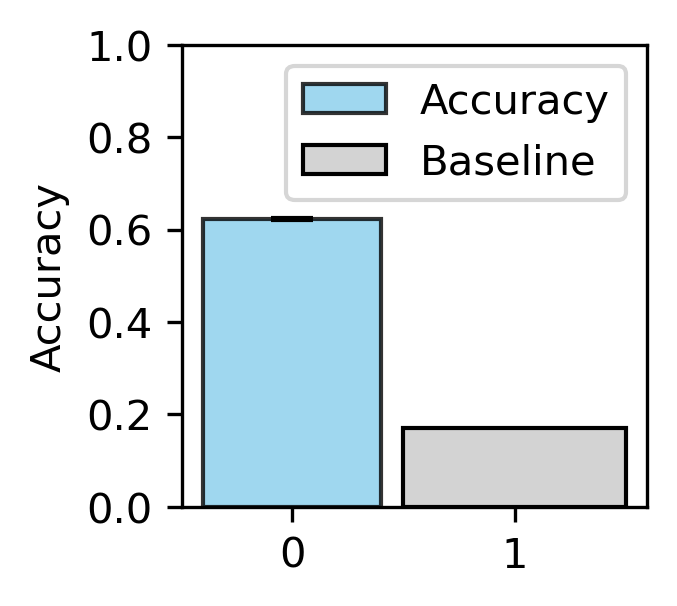

In [14]:
# meta_subset.study_name.value_counts()["LifeLinesDeep_2016"] / len(meta_subset)

# Values
score = [scores.mean()]
error = [scores.std()]
baseline = 0.17

labels = ["Study prediction"]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(2,2),dpi=300)

# Bar with error
ax.bar(x, score, yerr=error, capsize=5, label="Accuracy", color="skyblue", alpha=0.8, edgecolor="k", linewidth=1)

# Baseline bar next to it
ax.bar(x+1, [baseline], width=1, color="lightgray", label="Baseline", edgecolor="k", linewidth=1)

ax.set_xticks([0,1])
# ax.set_xticklabels(labels)
ax.set_ylabel("Accuracy")
ax.set_ylim(0,1)
ax.legend()

from scipy.stats import ttest_1samp

baseline = 0.17

t_stat, p_val = ttest_1samp(scores, baseline)
print(f"t={t_stat:.2f}, p={p_val:.3e}")

# fig.savefig("../fig/nw_study_predict.svg")

## 6. Main result: leave-studies-out ROC
Trains on all but a held-out set of studies, repeated over random study splits.

In [15]:
import random
import json

random.seed(42)

k_w = max(3, len(eligible_w_allsgb) // 2)
k_nw = max(3, len(eligible_nw_allsgb) // 2)

results = eval_leave_k_studies_out(
    X_allsgb,
    y_allsgb,
    filtered_allsgb,
    eligible_w_allsgb,
    eligible_nw_allsgb,
    k=k_w,  # robust leave-many-out for Western studies
    n_iters=30
)

with open("leave_k_studies_out_results.json", "w") as f:
    json.dump(results, f)


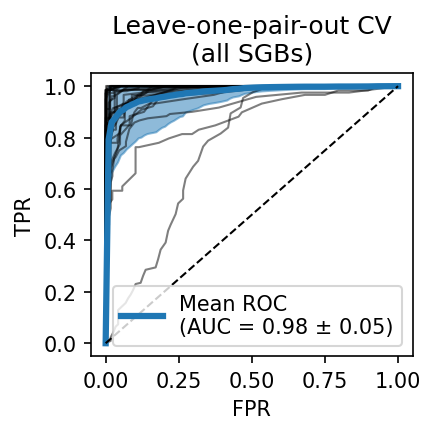

In [17]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from matplotlib import rcParams

def plot_leave2out_roc(
    json_path, 
    title="Leave-2-studies-out CV ROC curves", 
    subtitle="(all SGBs)",
    outfile=None
    ):
    # Load JSON data
    with open(json_path, 'r') as f:
        results = json.load(f)

    fpr_list = []
    tpr_list = []
    aucs = []

    mean_fpr = np.linspace(0, 1, 100)

    plt.figure(figsize=(3,3),dpi=150)

    for res in results:
        y_true = np.array(res["y_true"])
        y_proba = np.array(res["y_proba"])
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        # Interpolate to align all ROC curves to the same x-axis
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tpr_list.append(tpr_interp)

        plt.plot(fpr, tpr, color='k', lw=1, alpha=0.5)

    # Compute mean and std
    mean_tpr = np.mean(tpr_list, axis=0)
    std_tpr = np.std(tpr_list, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    # Plot mean ROC
    plt.plot(mean_fpr, mean_tpr, color='tab:blue', lw=3, label=f"Mean ROC\n(AUC = {mean_auc:.2f} ± {std_auc:.2f})")

    # Shaded std region
    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
    plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color='tab:blue', alpha=0.5)

    # Plot diagonal
    plt.plot([0, 1], [0, 1], 'k--', lw=1)

    # Aesthetics
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title}\n{subtitle}")
    plt.legend(loc="lower right")

    # # Remove upper and right axis
    # ax = plt.gca()
    # ax.spines['right'].set_visible(False)
    # ax.spines['top'].set_visible(False)
    
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, format=outfile.split(".")[-1])
    
    plt.show()


plot_leave2out_roc(
    json_path = "test.json",
    title = "Leave-one-pair-out CV",
    outfile="../fig/testfig.svg"
    )

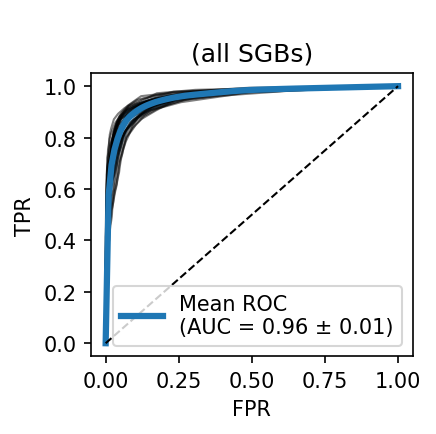

In [18]:
with open("leave_k_studies_out_results.json", 'r') as f:
    results = json.load(f)
plot_leave2out_roc(json_path="leave_k_studies_out_results.json", title="", outfile="../fig/kfold_cv_classifier.svg")

## 7. Example feature: *P. copri* abundance by lifestyle

In [ ]:
feature = "Prevotella copri clade C (SGB1644)"
ftable = adults_abundances[feature].reset_index().rename(columns={"index":"sample_id"}).merge(
    adults_metadata[["study_name","non_westernized"]].reset_index().rename(columns={"index":"sample_id"}))

fig, ax = plt.subplots(dpi=150, figsize=(3,4))
sns.boxplot(data=ftable, x="non_westernized", y=feature)
ax.set_xlabel("")

# sgb_name = feature.split(" (")[0]
# genus, species = sgb_name.split(" ")
# sgb_id = feature.split("(")[1][:-1]
# ax.set_ylabel(f"$\it{genus}$ $\it{species}$ ({sgb_id})")
ax.set_xticklabels(["W","NW"])

In [ ]:
exclude = ["Obregon-TitoAJ_2015","RampelliS_2015"]
ftable = ftable[~ftable.study_name.isin(exclude)]
nonwestmapping = (
    ftable.groupby("study_name")["non_westernized"]
    .value_counts()
    .reset_index(name="count")[["study_name", "non_westernized"]]
    .set_index("study_name")["non_westernized"]
    .to_dict()
)

groupvals = ftable.groupby("study_name")[feature].mean().reset_index()
groupvals["study_nonwest"] = groupvals.study_name.map(nonwestmapping)

fig, ax = plt.subplots(dpi=250, figsize=(2,4))
sns.boxplot(data=groupvals, x="study_nonwest", y=feature, palette=["#397797","#d5d53e"])
sns.stripplot(data=groupvals, x="study_nonwest", y=feature, color="black", alpha=.75)
fig.savefig("../fig/p_copri_abundance.svg")

## 8. Feature importance
Uses `results`, which section 6 just loaded from `leave_k_studies_out_results.json`. Run this section before section 9, which reassigns `results` to a different run.

In [ ]:
max(list(results[0]['feature_importances'].keys()))

In [ ]:
fi_summ = np.array([list(i['feature_importances'].values()) for i in results])
mean_fi = list(fi_summ.mean(axis=0))
std_fi = list(fi_summ.std(axis=0))
fi_final = pd.DataFrame(
    {
        "sgb_id":adults_abundances.columns,
        "mean_fi":mean_fi,
        "std_fi":std_fi
    })


# for n, val in enumerate(list(fi_summ.sum(axis=0) / 30)):
#     fi_final.append((sgb_number_to_name[n], val))

In [ ]:
fi_final

In [ ]:
fi_final_ranked = fi_final.sort_values(by='mean_fi', ascending=False).reset_index(drop=True).reset_index().rename(columns={"index":"fi_rank"})

In [ ]:
fi_final_ranked

In [ ]:
sample_to_lifestyle = dict(zip(adults_metadata.sample_id, adults_metadata.non_westernized))
wnw_ratio = adults_abundances.copy()
wnw_ratio["non_westernized"] = [sample_to_lifestyle[i] for i in adults_abundances.index]

wnw_ratio_abundances = (wnw_ratio.groupby("non_westernized").mean().loc["no"] + 1e-6) / (wnw_ratio.groupby("non_westernized").mean().loc["yes"] + 1e-6)

wnw_ratio = wnw_ratio.astype(bool).astype(int)
wnw_ratio["non_westernized"] = [sample_to_lifestyle[i] for i in adults_abundances.index]

wnw_ratio_prev = wnw_ratio.groupby("non_westernized").sum() + 1
n_w, n_nw = wnw_ratio.non_westernized.value_counts()
wnw_ratio_prev = (wnw_ratio_prev.loc["no"] / n_w) / (wnw_ratio_prev.loc["yes"] / n_nw)

In [ ]:
sgbcols = wnw_ratio.columns[:-1]
prev_in_w = wnw_ratio[wnw_ratio.non_westernized=="no"][sgbcols].sum() / wnw_ratio.non_westernized.value_counts()["no"]
prev_in_w

In [ ]:
# Sort by feature importance rank and take top 20
top20 = fi_final_ranked.sort_values("fi_rank").head(20)

prev_ratios = wnw_ratio_prev[top20.sgb_id].reset_index()
prev_ratios.columns = ["sgb_id", "prevalence_ratio"]
top20 = top20.merge(prev_ratios, on="sgb_id")

In [ ]:
top20["color"] = top20["prevalence_ratio"].apply(lambda x: "#397797" if x > 1 else "#d5d53e")

In [ ]:
# top20 and its "color" column (by prevalence ratio) come from the two cells above

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(6,4),dpi=150)

bars = ax.barh(
    top20["sgb_id"],
    top20["mean_fi"],
    xerr=top20["std_fi"],
    color=top20["color"],
    edgecolor="black",
    capsize=2
)

ax.invert_yaxis()  # highest rank at top
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#397797", edgecolor="black", label="PR > 1"),
    Patch(facecolor="#d5d53e", edgecolor="black", label="PR < 1")
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
# fig.savefig("../fig/top20fi.svg")
plt.show()


In [ ]:
prev_in_w_top = prev_in_w[top20.sgb_id].reset_index()
prev_in_w_top.columns = ["sgb_id","prev_in_w"]

# Sort by feature importance rank and take top 20
# top20 = fi_final_ranked.sort_values("fi_rank").head(20)
top20 = top20.merge(prev_in_w_top, on="sgb_id")


# Normalize prevalence for colormap
norm = mcolors.Normalize(vmin=top20["prev_in_w"].min(), vmax=top20["prev_in_w"].max())

# Choose red-blue colormap
cmap = plt.cm.RdBu_r  # reversed red-blue

# Assign colors based on normalized prevalence in W
top20["color"] = top20["prev_in_w"].apply(lambda x: cmap(norm(x)))

# Plot horizontal bar chart with error bars and caps
fig, ax = plt.subplots(figsize=(6,4),dpi=150)
bars = ax.barh(
    top20["sgb_id"],
    top20["mean_fi"],
    xerr=top20["std_fi"],
    color=top20["color"],
    edgecolor="black",
    capsize=2
)

ax.invert_yaxis()  # highest rank at top
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("")

plt.tight_layout()
# fig.savefig("../fig/top20fi_westprev.svg")
plt.show()


In [ ]:
fi_final_ranked.to_csv("../data/nw_classifier_feature_importances.tsv", sep="\t", index=False)

In [ ]:
fi_final_ranked['sgb_num'] = fi_final_ranked.sgb_id.apply(lambda x: x.split('(')[1][:-1])

In [ ]:
fi_final_ranked[fi_final_ranked.sgb_num == 'SGB5809_group']

In [ ]:
plot_leave2out_roc(
    json_path="leave_k_studies_out_results_perm.json", 
    title="", 
    outfile="../fig/kfold_cv_classifier_permuted2.svg"
)